=== Dataset Overview ===
      dataset    rows  columns  duplicates  missing_cells  rows_with_missing
0      orders   99441        8           0           4908               2980
1       items  112650        7           0              0                  0
2    payments  103886        5           0              0                  0
3     reviews  100000        7           0         146532              90014
4   customers   99441        5           0              0                  0
5    products   32951        9           0           2448                611
6     sellers    3095        4           0              0                  0
7  categories      71        2           0              0                  0

=== Missing Values by Dataset ===

orders
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

items
No missing values

payments
No missing values

reviews
review_comment_title      88285
review_comment_mes

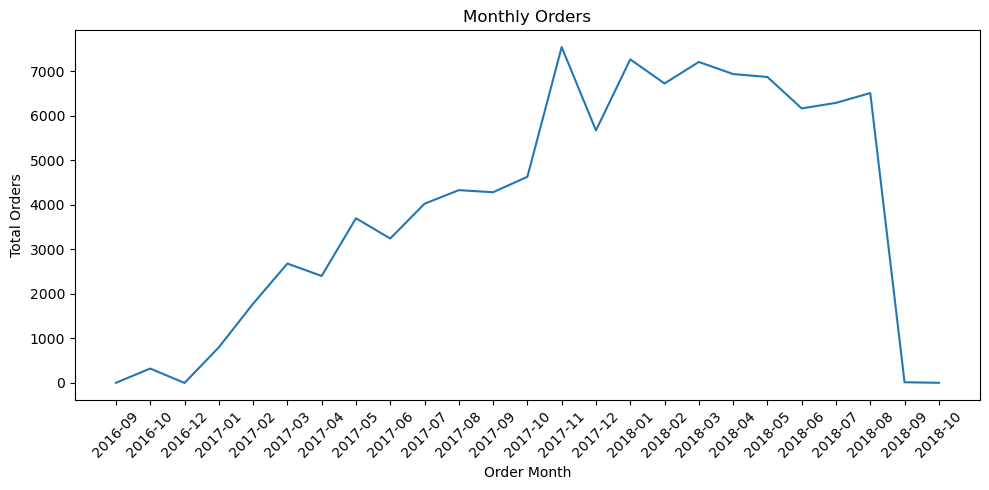


=== Price Summary ===
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

=== Freight Summary ===
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64


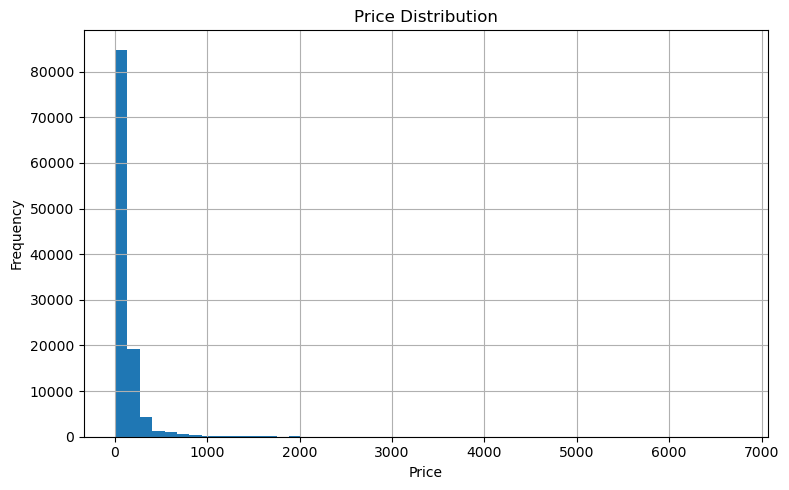

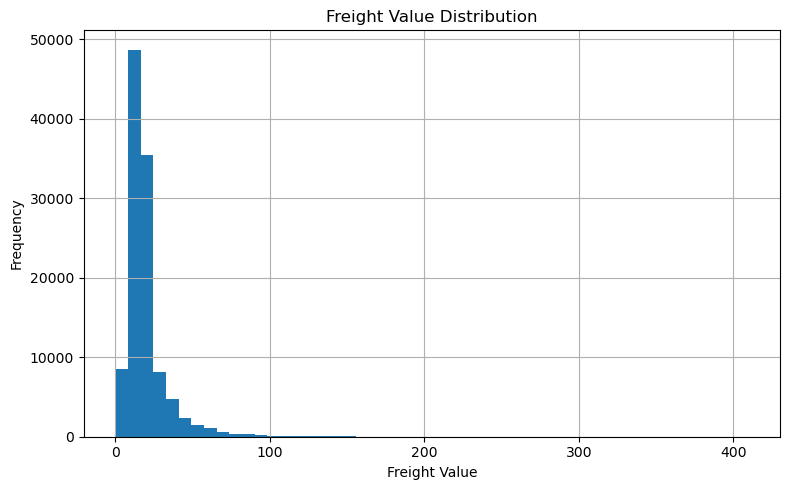


=== Products Missing Analysis ===
product_category_name         610
product_description_lenght    610
product_name_lenght           610
product_photos_qty            610
product_weight_g                2
product_height_cm               2
product_length_cm               2
product_width_cm                2
dtype: int64

=== Top 10 Categories by Item Count ===
product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64


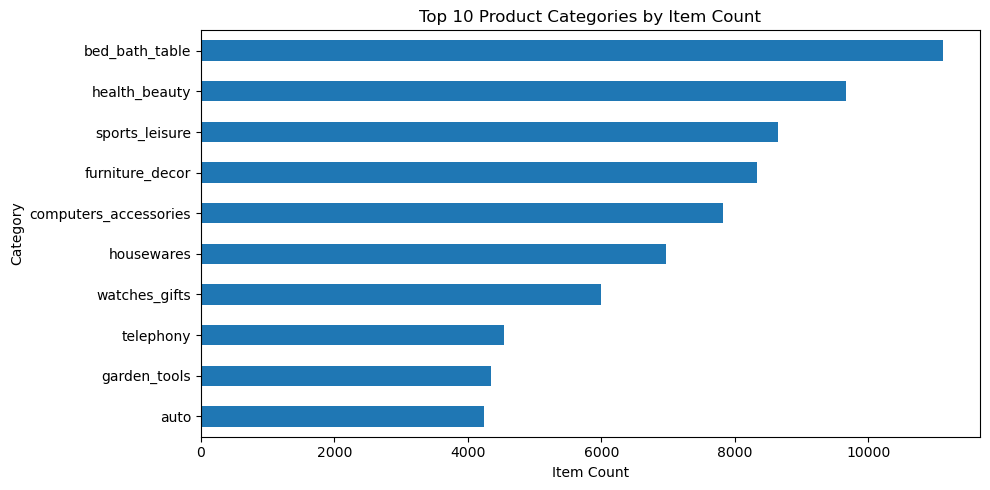

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# Load datasets
# ============================
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
categories = pd.read_csv("../data/raw/product_category_name_translation.csv")

datasets = {
    "orders": orders,
    "items": items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "categories": categories
}

# ============================
# Basic overview (improved)
# ============================
summary = []

for name, df in datasets.items():
    summary.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicates": df.duplicated().sum(),
        "missing_cells": df.isna().sum().sum(),
        "rows_with_missing": df.isna().any(axis=1).sum()
    })

summary_df = pd.DataFrame(summary)

print("=== Dataset Overview ===")
print(summary_df)

print("\n=== Missing Values by Dataset ===")
for name, df in datasets.items():
    missing_by_col = df.isna().sum()
    missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)

    print(f"\n{name}")
    if len(missing_by_col) == 0:
        print("No missing values")
    else:
        print(missing_by_col)

# ============================
# Reviews missing analysis
# ============================
print("\n=== Reviews Missing Analysis ===")
reviews_missing = reviews.isna().sum().sort_values(ascending=False)
reviews_missing = reviews_missing[reviews_missing > 0]

if len(reviews_missing) == 0:
    print("No missing values in reviews dataset")
else:
    print(reviews_missing)

# Add a flag to indicate whether a review has text comment
reviews["has_comment"] = reviews["review_comment_message"].notna()

print("\n=== Reviews with vs without comments ===")
print(reviews["has_comment"].value_counts())

print("\n=== Average Review Score by Comment Presence ===")
print(reviews.groupby("has_comment")["review_score"].mean())

# ============================
# Orders exploration
# ============================
print("\n=== Order Status Distribution ===")
print(orders["order_status"].value_counts())

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"], errors="coerce"
)
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly_orders = (
    orders.groupby("order_month")["order_id"]
    .count()
    .reset_index(name="total_orders")
    .sort_values("order_month")
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_orders["order_month"], monthly_orders["total_orders"])
plt.xticks(rotation=45)
plt.title("Monthly Orders")
plt.xlabel("Order Month")
plt.ylabel("Total Orders")
plt.tight_layout()
plt.show()

# ============================
# Items exploration
# ============================
print("\n=== Price Summary ===")
print(items["price"].describe())

print("\n=== Freight Summary ===")
print(items["freight_value"].describe())

plt.figure(figsize=(8, 5))
items["price"].dropna().hist(bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
items["freight_value"].dropna().hist(bins=50)
plt.title("Freight Value Distribution")
plt.xlabel("Freight Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================
# Products missing analysis
# ============================
print("\n=== Products Missing Analysis ===")
products_missing = products.isna().sum().sort_values(ascending=False)
products_missing = products_missing[products_missing > 0]

if len(products_missing) == 0:
    print("No missing values in products dataset")
else:
    print(products_missing)

# ============================
# Top categories by item count
# ============================
products_cat = products.merge(
    categories,
    on="product_category_name",
    how="left"
)

items_cat = items.merge(
    products_cat[["product_id", "product_category_name_english"]],
    on="product_id",
    how="left"
)

top_categories = (
    items_cat["product_category_name_english"]
    .fillna("unknown")
    .value_counts()
    .head(10)
)

print("\n=== Top 10 Categories by Item Count ===")
print(top_categories)

plt.figure(figsize=(10, 5))
top_categories.sort_values().plot(kind="barh")
plt.title("Top 10 Product Categories by Item Count")
plt.xlabel("Item Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()